In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("company_esg_financial_dataset.csv")
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

CompanyID               0
CompanyName             0
Industry                0
Region                  0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
dtype: int64

In [4]:
df = df.dropna()

In [6]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df

,companyid,companyname,industry,region,year,revenue,profitmargin,marketcap,growthrate,esg_overall,esg_environmental,esg_social,esg_governance,carbonemissions,waterusage,energyconsumption
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8
5,1,Company_1,Retail,Latin America,2020,567.5,6.0,384.1,2.3,55.7,65.1,28.5,73.5,42245.4,21122.7,84490.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,1000,Company_1000,Consumer Goods,Latin America,2021,3419.2,21.7,14416.7,0.4,52.2,67.2,46.3,43.1,498875.8,623594.7,2494378.8
10996,1000,Company_1000,Consumer Goods,Latin America,2022,3518.8,21.4,8078.9,2.9,51.9,68.7,44.7,42.3,506013.7,632517.1,2530068.4
10997,1000,Company_1000,Consumer Goods,Latin America,2023,3417.1,17.1,13263.4,-2.9,52.9,72.4,43.1,43.2,473561.5,591951.9,2367807.7
10998,1000,Company_1000,Consumer Goods,Latin America,2024,3183.2,15.7,6960.1,-6.8,52.0,72.4,40.5,42.9,441310.9,551638.6,2206554.3


In [9]:
df['esg_score'] = (
 0.4 * df['esg_environmental'] +
 0.3 * df['esg_social'] +
 0.3 * df['esg_governance']
)

In [10]:
def classify(score):
    if score >= 70:
        return "Low Risk"
    elif score >= 50:
        return "Medium Risk"
    else:
        return "High Risk"
df['risk_category'] = df['esg_score'].apply(classify)

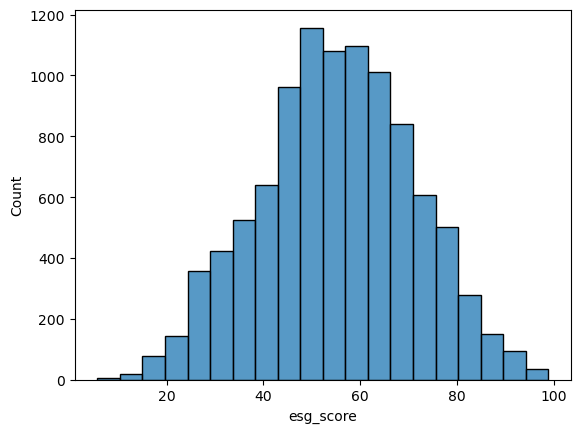

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['esg_score'], bins=20)
plt.show()

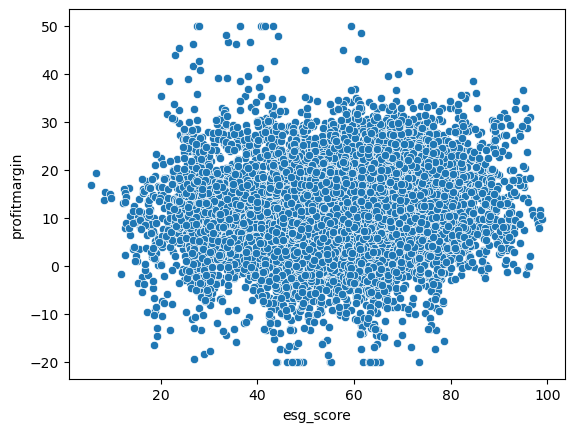

In [15]:
sns.scatterplot(x=df['esg_score'], y=df['profitmargin'])
plt.show()

In [17]:
df.groupby('industry')['esg_score'].mean().sort_values()

industry
Transportation    45.170709
Energy            48.443630
Manufacturing     49.912017
Utilities         51.404860
Consumer Goods    54.927500
Retail            56.241981
Healthcare        58.479008
Technology        65.687400
Finance           67.429912
Name: esg_score, dtype: float64

C:\Users\Acer\AppData\Local\Temp\ipykernel_4708\954606326.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


<Axes: >

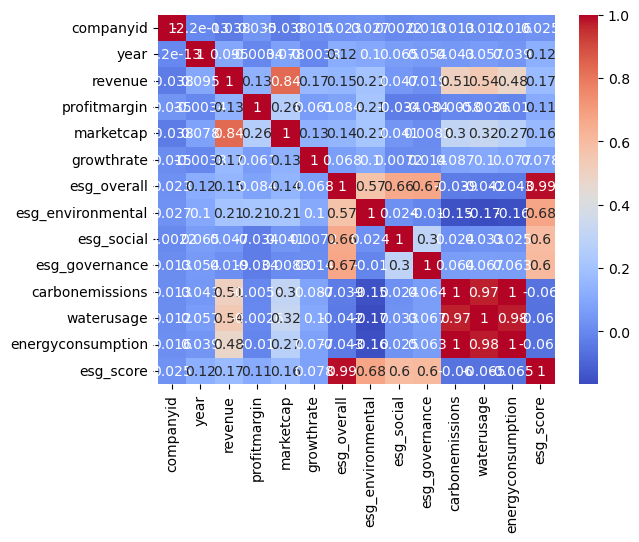

In [18]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [19]:
from sklearn.cluster import KMeans
features = df[['esg_environmental', 'esg_social', 'esg_governance']]
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(features)

C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


AttributeError: 'NoneType' object has no attribute 'split'

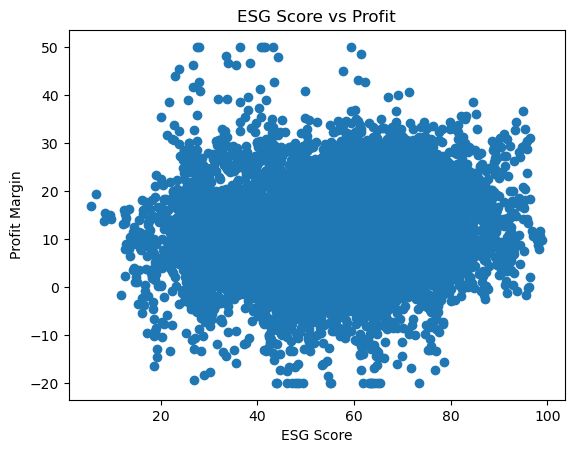

In [20]:
import matplotlib.pyplot as plt
plt.scatter(df['esg_score'], df['profitmargin'])
plt.xlabel("ESG Score")
plt.ylabel("Profit Margin")
plt.title("ESG Score vs Profit")
plt.show()

In [21]:
df.head()

,companyid,companyname,industry,region,year,revenue,profitmargin,marketcap,growthrate,esg_overall,esg_environmental,esg_social,esg_governance,carbonemissions,waterusage,energyconsumption,esg_score,risk_category
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4,56.95,Medium Risk
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9,56.58,Medium Risk
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2,58.43,Medium Risk
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8,57.31,Medium Risk
5,1,Company_1,Retail,Latin America,2020,567.5,6.0,384.1,2.3,55.7,65.1,28.5,73.5,42245.4,21122.7,84490.9,56.64,Medium Risk


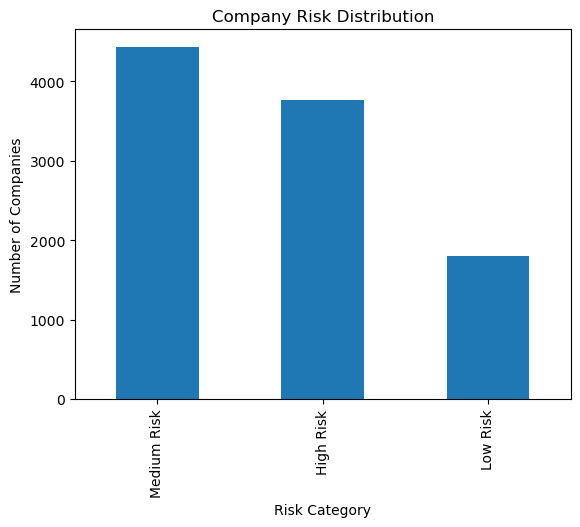

In [23]:
df['risk_category'].value_counts().plot(kind='bar')
plt.title("Company Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Companies")
plt.show()

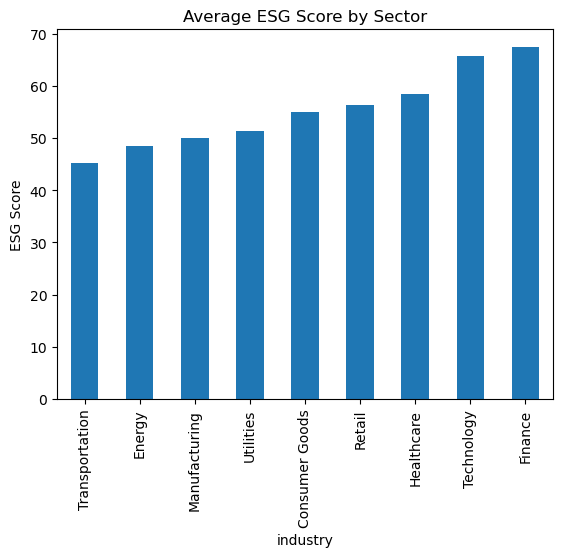

In [24]:
sector_esg = df.groupby('industry')['esg_score'].mean().sort_values()
sector_esg.plot(kind='bar')
plt.title("Average ESG Score by Sector")
plt.ylabel("ESG Score")
plt.show()

In [25]:
df.sort_values(by='esg_score', ascending=False).head(10)

,companyid,companyname,industry,region,year,revenue,profitmargin,marketcap,growthrate,esg_overall,esg_environmental,esg_social,esg_governance,carbonemissions,waterusage,energyconsumption,esg_score,risk_category
5255,478,Company_478,Finance,Europe,2023,11534.2,9.8,12115.6,11.1,98.8,100.0,100.0,96.3,115341.6,57670.8,288353.9,98.89,Low Risk
5256,478,Company_478,Finance,Europe,2024,11424.6,10.6,13965.0,-0.9,98.3,100.0,100.0,94.9,114245.9,57122.9,285614.7,98.47,Low Risk
5252,478,Company_478,Finance,Europe,2020,11330.8,11.6,16094.0,4.2,98.2,100.0,100.0,94.6,113307.9,56653.9,283269.7,98.38,Low Risk
5257,478,Company_478,Finance,Europe,2025,11483.5,7.9,15330.3,0.5,98.0,100.0,100.0,94.0,114835.2,57417.6,287088.0,98.20,Low Risk
5254,478,Company_478,Finance,Europe,2022,10378.7,8.8,12644.8,-3.0,97.8,100.0,99.0,94.5,103827.1,51913.6,259567.8,98.05,Low Risk
5253,478,Company_478,Finance,Europe,2021,10703.0,9.7,20031.1,-5.5,97.7,99.6,100.0,93.5,107689.2,53844.6,269223.1,97.89,Low Risk
5251,478,Company_478,Finance,Europe,2019,10871.3,10.7,22787.5,0.3,96.9,98.2,100.0,92.4,111402.8,55701.4,278507.0,97.00,Low Risk
5250,478,Company_478,Finance,Europe,2018,10837.1,11.7,24150.1,-2.7,96.7,97.7,99.8,92.6,111790.8,55895.4,279477.1,96.80,Low Risk
9569,870,Company_870,Finance,Latin America,2025,10588.4,2.0,2859.0,10.0,96.0,100.0,93.3,94.7,105884.1,52942.1,264710.3,96.40,Low Risk
3877,353,Company_353,Finance,Europe,2020,2921.4,31.1,11958.5,18.1,96.0,100.0,89.2,98.7,29213.7,14606.8,73034.2,96.37,Low Risk


In [26]:
df.to_csv("esg_final_data.csv", index=False)